In [1]:
import sys
#TODO change hardcoding
sys.path.append('../../../')
from concurrent.futures import process
import os
import glob
from posixpath import dirname
import re
from turtle import pd
from cv2 import THRESH_BINARY_INV, THRESH_OTSU
import numpy as np
from requests import delete
import cv2
import pyvips as Vips
from tqdm import tqdm
import pyfiglet
import argparse
import pdb
import skimage.io as io
#from src.utils import vips_utils, normalize
import matplotlib.pyplot as plt
from skimage.io import imread, imsave

import time
from timeit import default_timer as timer
from threading import Thread
from concurrent.futures import ThreadPoolExecutor, wait, ALL_COMPLETED
import subprocess
import geojson
import os
from PIL import Image

In [2]:
import pyvips as Vips

class Reinhard(object):
    """
    A stain normalization object for PyVips.
    fits a reference PyVips image,
    transforms a PyVips Image.
    Can also be initialized with precalculated
    means and stds (in LAB colorspace)
    """

    def __init__(self, target_means=None, target_stds=None):
        self.target_means = target_means
        self.target_stds  = target_stds

    def fit(self, target): 
        """
        target is a PyVips Image object
        """
        means, stds = self.get_mean_std(target)
        self.target_means = means
        self.target_stds  = stds
    
    def transform(self, image):
        L, A, B = self.lab_split(image)
        means, stds = self.get_mean_std(image)
        norm1 = ((L - means[0]) * (self.target_stds[0] / stds[0])) + self.target_means[0]
        norm2 = ((A - means[1]) * (self.target_stds[1] / stds[1])) + self.target_means[1]
        norm3 = ((B - means[2]) * (self.target_stds[2] / stds[2])) + self.target_means[2]
        return self.merge_to_rgb(norm1, norm2, norm3)
    
    def lab_split(self, img):
        img_lab = img.colourspace("VIPS_INTERPRETATION_LAB")
        L, A, B = img_lab.bandsplit()[:3]
        return L, A, B
        
    def get_mean_std(self, image):
        L, A, B = self.lab_split(image)
        m1, sd1 = L.avg(), L.deviate()
        m2, sd2 = A.avg(), A.deviate()
        m3, sd3 = B.avg(), B.deviate()
        means = m1, m2, m3
        stds  = sd1, sd2, sd3
        self.image_stats = means, stds
        return means, stds
    
    def merge_to_rgb(self, L, A, B):
        img_lab = L.bandjoin([A,B])
        img_rgb = img_lab.colourspace('VIPS_INTERPRETATION_sRGB')
        return img_rgb

In [3]:
def normalization(REF_IMG_PATH):
    print("Init Normalization")
    ref_image = Vips.Image.new_from_file(REF_IMG_PATH)
    normalizer = Reinhard()
    normalizer.fit(ref_image)
    return normalizer

In [4]:
dlb_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases"
pdd_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases"
wsi_home_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/"

In [5]:
json_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/GeoJsons"

In [6]:
f_list = os.listdir(json_dir)
f_list.remove('.DS_Store')

In [7]:
f_list

['PD753_aSyn_CG_x400.svs (2).geojson',
 'PD102_SYN1_CG.svs.geojson',
 '13_131_CG_aSyn_x200.svs.geojson',
 '12_007_CG_aSyn_x200.svs.geojson',
 'PD079_SYN1_CG.svs.geojson',
 '13_177_CG_aSyn_x200.svs.geojson',
 'PD088_SYN1_CG.svs.geojson',
 'PD110_SYN1_CG.svs.geojson',
 'PD001_Syn1_CG.svs.geojson',
 'PD034_SYN1_CG.svs.geojson',
 'PD113_SYN1_CG.svs.geojson',
 'PD002_SYN1_CG.svs.geojson',
 '11_063_CG_aSyn_x200.svs.geojson',
 'PD041_SYN1_CG.svs.geojson',
 '12_060_CG_aSyn_x200.svs.geojson',
 'PD753_aSyn_CG_x400.svs.geojson',
 'PD017_SYN1_CG.svs.geojson']

In [8]:
#imagenames = sorted(glob.glob(os.path.join(wsi_home_dir, './*/*.svs')))
imagenames = sorted(glob.glob(os.path.join(dlb_wsi_dir, './*.svs')))

In [9]:
imagenames

['/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./11_063_CG_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./11_063_EntCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./11_063_FCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./11_063_PCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./11_063_TCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./12_007_CG_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./12_007_EntCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./12_007_FCx_aSyn_x200.svs',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/./12_060_C

In [10]:
for i in f_list:
    with open(os.path.join(json_dir,i)) as f:
        gj = geojson.load(f)
    features = gj['features']
    #print(len(features))
    if len(features)>0:
        print(i)
        print(len(features[0]['geometry']['coordinates'][0]))
    

13_131_CG_aSyn_x200.svs.geojson
5
PD079_SYN1_CG.svs.geojson
1351
13_177_CG_aSyn_x200.svs.geojson
5
PD034_SYN1_CG.svs.geojson
1045
11_063_CG_aSyn_x200.svs.geojson
5
PD041_SYN1_CG.svs.geojson
797
12_060_CG_aSyn_x200.svs.geojson
5
PD017_SYN1_CG.svs.geojson
1021


In [9]:
tilesize = 1024
workers = 10
save_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images2"
stride = 256
REF_IMG_PATH = imagenames[0]

def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

def get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,stride):
    points = []
    stride = stride
    for x_val in range(x, x+downscaled_w-stride, stride): 
        for y_val in range(y, y + downscaled_h-stride, stride): 
            inside = cv2.pointPolygonTest(cnt, (x_val, y_val), False) 
            if inside >= 0: 
                points.append((x_val, y_val)) # points time scale factor print(f'Collected {len(self.points)} points') return self.points 
    return points

def crop_process(i, x, y, vips_orig_img, savesubdir, orig_w, orig_h):   
    print("Crop slide thread Started.", i) 
    savecroppath = os.path.join(savesubdir, f'{filename}_x_{x}_y_{y}.png')
    # row is y, col is x
    if y + tilesize < orig_h and x + tilesize < orig_w:
        # TODO change to vips cropping
        print("---------copying image---------")
        crop = vips_orig_img.crop(x, y, 1024, 1024)
        crop.write_to_file(savecroppath)
    print("Thread Stopped ", i)


def tiling(cnt,vips_img, vips_array_copy, filename, class_type, orig_w, orig_h):
    cnt = cnt.astype(np.int)
    x,y,downscaled_w,downscaled_h = cv2.boundingRect(cnt)
    vips_array_copy = cv2.drawContours(vips_array_copy, [cnt],-1, (0,0,255),3)
    vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),20)
    points = get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,stride)
    for x, y in points:
        vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + tilesize,y + tilesize),(255,0,0),20)
    th = Image.fromarray(vips_array_copy)
    th.thumbnail((1000,1000))
    th.save(os.path.join(save_dir,filename.split(".")[0]+".png"))
    savesubdir = os.path.join(save_dir, class_type)
    exe = ThreadPoolExecutor(max_workers=workers)
    futures = [exe.submit(crop_process, i, x_1, y_1, vips_img, savesubdir, orig_w, orig_h) for i, (x_1, y_1) in enumerate(points)]
    done, not_done = wait(futures, return_when=ALL_COMPLETED)
    exe.shutdown()
    return "done tiling"

In [10]:
normalizer = normalization(REF_IMG_PATH)

Init Normalization


In [26]:
im = Vips.Image.new_from_file(imagenames[1])
normalized_image = normalizer.transform(im)

In [11]:
for img in imagenames:
    filename = img.split("/")[-1]
    geo_name = filename+".geojson"
    if geo_name in f_list:
        with open(os.path.join(json_dir,geo_name)) as f:
            gj = geojson.load(f)
        features = gj['features']
        print(geo_name, len(features))
        if len(features)!=0:
            vips_img = Vips.Image.new_from_file(img, level=0)
            vips_img = normalizer.transform(vips_img)
            vinfo = getVipsInfo(vips_img)
            orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
            vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
            vips_array = vips_array[:,:,:3]
            vips_array_copy =vips_array.copy()
            for j in features:
                coords = j["geometry"]["coordinates"]
                class_type = j["properties"]["classification"]["names"][0]
                print(len(coords[0]))
                cnt = np.array(coords[0])
                print(len(cnt.shape))
                if len(cnt.shape)==2:
                    tiling(cnt,vips_img, vips_array_copy, filename, class_type, orig_w, orig_h)
                else:
                    print(filename, cnt.shape)

11_063_CG_aSyn_x200.svs.geojson 8
5
2


/tmp/ipykernel_82921/1114709676.py:37: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  cnt = cnt.astype(np.int)


Crop slide thread Started. 0
---------copying image---------
Crop slide thread Started. 1
---------copying image---------
Crop slide thread Started. 2
---------copying image---------
Crop slide thread Started. 3
---------copying image---------
Crop slide thread Started. 4
---------copying image---------
Crop slide thread Started. 5
---------copying image---------
Crop slide thread Started. 6
---------copying image---------
Crop slide thread Started. 7
---------copying image---------
Crop slide thread Started. 8
---------copying image---------
Crop slide thread Started. 9
---------copying image---------
Thread Stopped  5
Crop slide thread Started. 10
---------copying image---------
Thread Stopped  4
Crop slide thread Started. 11
---------copying image---------
Thread Stopped  9
Crop slide thread Started. 12
---------copying image---------
Thread Stopped  3
Crop slide thread Started. 13
---------copying image---------
Thread Stopped  1
Thread Stopped  2
Crop slide thread Started. 14
----

/tmp/ipykernel_82921/1927808809.py:21: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  cnt = np.array(coords[0])


Crop slide thread Started. 0
---------copying image---------
Crop slide thread Started. 1
---------copying image---------
Crop slide thread Started. 2
---------copying image---------
Crop slide thread Started. 3
---------copying image---------
Crop slide thread Started. 4
---------copying image---------
Crop slide thread Started. 5
---------copying image---------
Crop slide thread Started. 6
---------copying image---------
Crop slide thread Started. 7
---------copying image---------
Crop slide thread Started. 8
---------copying image---------
Crop slide thread Started. 9
---------copying image---------
Thread Stopped  2
Crop slide thread Started. 10
---------copying image---------
Thread Stopped  7
Crop slide thread Started. 11
---------copying image---------
Thread Stopped  8
Crop slide thread Started. 12
---------copying image---------
Thread Stopped  4
Crop slide thread Started. 13
---------copying image---------
Thread Stopped  5
Crop slide thread Started. 14
---------copying image

In [ ]:
for img in imagenames:
    filename = img.split("/")[-1]
    geo_name = filename+".geojson"
    if geo_name in f_list:
        print(geo_name)
        with open(os.path.join(json_dir,geo_name)) as f:
            gj = geojson.load(f)
        features = gj['features']
        print(len(features))
        if len(features)==0:
            continue
        vips_img = Vips.Image.new_from_file(img, level=0)
        vinfo = getVipsInfo(vips_img)
        orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
        vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
        vips_array = vips_array[:,:,:3]
        vips_array_copy =vips_array.copy()
        for j in features:
            coords = j["geometry"]["coordinates"]
            class_type = j["properties"]["classification"]["names"][0]
            print(len(coords[0]))
            #if len(coords[0])>1:
            #    for k in range(len(coords[0])):
            #        cnt = np.array(coords[0][k]).astype(np.int)
            #else:
            cnt = np.array(coords[0])
            print(len(cnt.shape))
            if len(cnt.shape)==2:
                cnt = cnt.astype(np.int)
                x,y,downscaled_w,downscaled_h = cv2.boundingRect(cnt)
                vips_array_copy = cv2.drawContours(vips_array_copy, [cnt],-1, (0,0,255),3)
                vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),20)
                points = get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,stride)
                for x, y in points:
                    vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + tilesize,y + tilesize),(255,0,0),20)
                th = Image.fromarray(vips_array_copy)
                th.thumbnail((1000,1000))
                th.save(os.path.join(save_dir,filename.split(".")[0]+".png"))
                savesubdir = os.path.join(save_dir, filename, class_type)
                os.makedirs(savesubdir, exist_ok=True)
                exe = ThreadPoolExecutor(max_workers=workers)
                futures = [exe.submit(crop_process, i, x_1, y_1, vips_img, savesubdir, orig_w, orig_h) for i, (x_1, y_1) in enumerate(points)]
                done, not_done = wait(futures, return_when=ALL_COMPLETED)
                exe.shutdown()
            else:
                print(filename, cnt.shape)


In [234]:
cnt = np.array(coords[0]).astype(int)
x,y,downscaled_w,downscaled_h = cv2.boundingRect(cnt)

In [187]:
x,y,downscaled_w,downscaled_h

(24214, 2930, 16362, 19935)

In [235]:
vips_array2 = cv2.rectangle(vips_array2,(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),20)

In [188]:
vips_array = cv2.rectangle(vips_array.copy(),(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),20)

In [239]:
j=features[0]
coords = j["geometry"]["coordinates"]
class_type = j["properties"]["classification"]["names"][0]

In [240]:
class_type

'White'

In [241]:
coords[0]

[[16761, 2934],
 [16664, 2944],
 [16570, 2972],
 [16484, 3018],
 [16409, 3080],
 [16399.95, 3090.95],
 [16389, 3100],
 [16327, 3175],
 [16281, 3261],
 [16253, 3355],
 [16243, 3452],
 [16243, 3472],
 [16243, 3492],
 [16243, 3512],
 [16243, 3531],
 [16243, 3551],
 [16253, 3648],
 [16281, 3742],
 [16327, 3828],
 [16389, 3903],
 [16409, 3923],
 [16484, 3985],
 [16570, 4031],
 [16664, 4059],
 [16677.41, 4060.38],
 [16683, 4065],
 [16769, 4111],
 [16863, 4139],
 [16960, 4149],
 [16964.26, 4149],
 [16968, 4151],
 [16973.87, 4152.74],
 [17008, 4171],
 [17013.87, 4172.74],
 [17040.27, 4186.87],
 [17061, 4204],
 [17075.18, 4211.58],
 [17091, 4223],
 [17119.23, 4235.23],
 [17144, 4260],
 [17146, 4262],
 [17221, 4324],
 [17225.5, 4326.41],
 [17237.64, 4334.64],
 [17245, 4342],
 [17247.11, 4343.74],
 [17249, 4346],
 [17269.12, 4361.94],
 [17285.03, 4375.1],
 [17291.88, 4382.36],
 [17301, 4395],
 [17326.69, 4419.25],
 [17351, 4445],
 [17363.68, 4454.15],
 [17372, 4462],
 [17393.15, 4475.41],
 [17415

In [192]:
cnt

array([[35005,  2930],
       [34955,  2934],
       [34913,  2936],
       ...,
       [35618,  2944],
       [35475,  2930],
       [35005,  2930]])

In [215]:
[np.array(coords[0]).astype(int), np.array(coords[1]).astype(int)]

[array([[35005,  2930],
        [34955,  2934],
        [34913,  2936],
        ...,
        [35618,  2944],
        [35475,  2930],
        [35005,  2930]]),
 array([[26427,  6844],
        [26459,  6861],
        [26467,  6863],
        ...,
        [26446,  6919],
        [26429,  6848],
        [26427,  6844]])]

In [242]:
vips_array2 = cv2.drawContours(vips_array, [np.array(coords[0]).astype(int)],-1, (0,0,0),3)

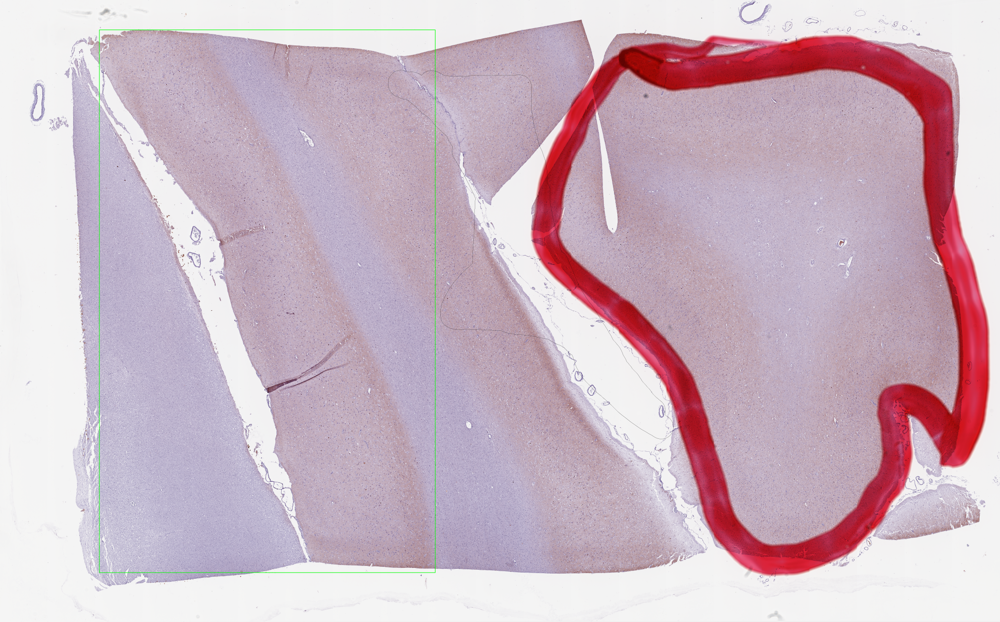

In [243]:
th = Image.fromarray(vips_array2)
th.thumbnail((1000,1000))
th

In [176]:
#vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
from PIL import Image
th = Image.fromarray(vips_array)
th.thumbnail((1000,1000))

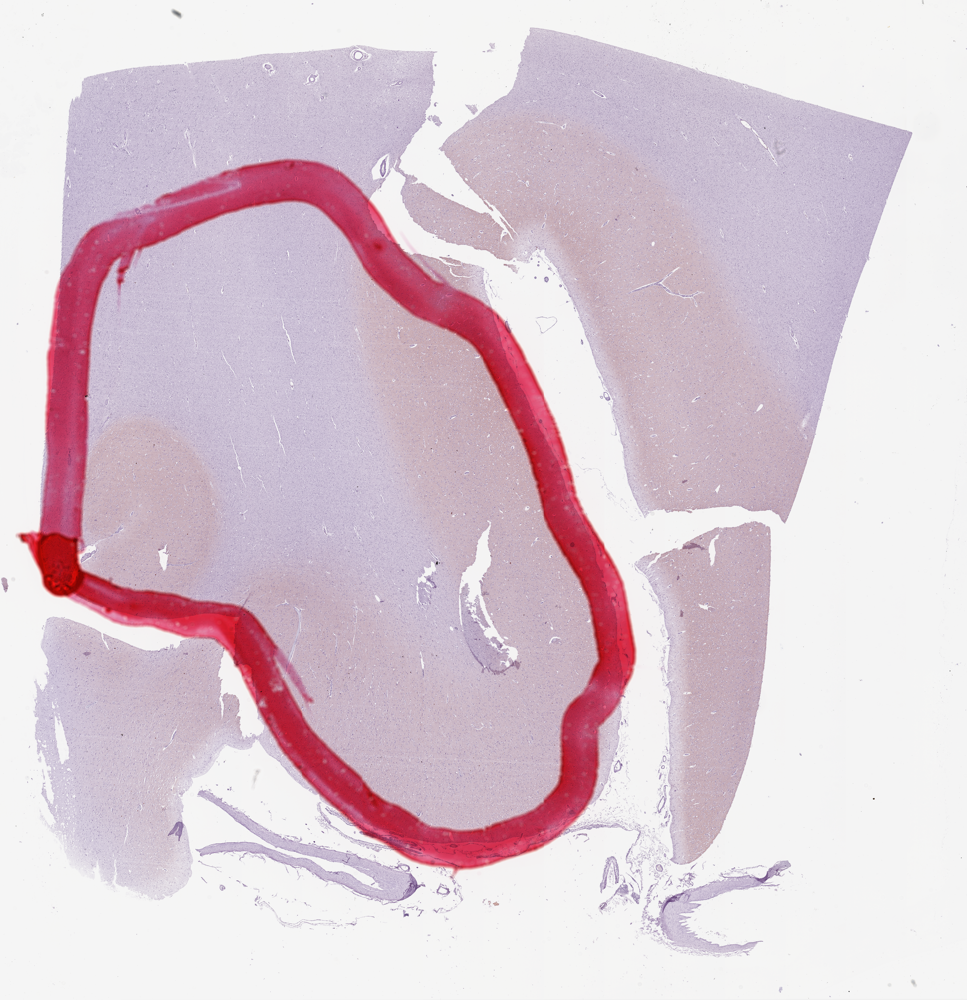

In [180]:
th

In [130]:
if "PD034_Syn1_CG.svs.geojson" in f_list:
    print("True")

In [131]:
f_list

['PD753_aSyn_CG_x400.svs (2).geojson',
 'PD102_SYN1_CG.svs.geojson',
 '12_007_CG_aSyn_x200.svs.geojson',
 'PD079_SYN1_CG.svs.geojson',
 'PD088_SYN1_CG.svs.geojson',
 'PD110_SYN1_CG.svs.geojson',
 'PD001_Syn1_CG.svs.geojson',
 'PD092_SYN1_FCX.svs.geojson',
 'PD034_SYN1_CG.svs.geojson',
 'PD113_SYN1_CG.svs.geojson',
 'PD002_SYN1_CG.svs.geojson',
 '11_063_CG_aSyn_x200.svs.geojson',
 'PD041_SYN1_CG.svs.geojson',
 '12_060_CG_aSyn_x200.svs.geojson',
 'PD753_aSyn_CG_x400.svs.geojson',
 'PD017_SYN1_CG.svs.geojson']

In [10]:
cnt = np.array(features["geometry"]["coordinates"][0]).astype(np.int)
#cnt = np.array([[1,0],[0,1],[0,0],[1,1]])
rect = cv2.minAreaRect(cnt)
box = cv2.boxPoints(rect)
box = np.int0(box)

/tmp/ipykernel_40697/2327601447.py:1: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  cnt = np.array(features["geometry"]["coordinates"][0]).astype(np.int)


In [ ]:
cnt = np.array(features["geometry"]["coordinates"][0]).astype(np.int)
#cnt = np.array([[1,0],[0,1],[0,0],[1,1]])
rect = cv2.minAreaRect(cnt)
box = cv2.boxPoints(rect)
box = np.int0(box)

In [11]:
box

array([[14557,  9908],
       [17558,   366],
       [30134,  4322],
       [27133, 13864]])

In [10]:
cnt = np.array(features["geometry"]["coordinates"][0])
cnt.shape

(1351, 2)

In [92]:
cnt.shape

(1351, 2)

In [61]:
pdd_wsi_dir

'gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases'

In [11]:
imagenames = sorted(glob.glob(os.path.join(wsi_home_dir, './*/*.svs')))

In [12]:
len(imagenames)

521

In [13]:
imagenames[0]

'/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'

In [14]:
vips_img = Vips.Image.new_from_file(imagenames[0], level=0)

In [19]:
vinfo = getVipsInfo(vips_img)
orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])

In [20]:
orig_w, orig_h

(53783, 33339)

In [21]:
vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))

In [22]:
vips_array.shape

(33339, 53783, 4)

In [23]:
vips_array = vips_array[:,:,:3]

In [24]:
vips_array.shape

(33339, 53783, 3)

In [24]:
x,y,downscaled_w,downscaled_h = box

In [25]:
downscaled_w

array([30134,  4322])

In [91]:
box

array([[14557,  9908],
       [17558,   366],
       [30134,  4322],
       [27133, 13864]])

In [25]:
cnt

array([[18126.,   881.],
       [18100.,   882.],
       [18073.,   884.],
       ...,
       [18179.,   884.],
       [18152.,   882.],
       [18126.,   881.]])

In [26]:
cnt.max(), cnt.min()

(30025.0, 881.0)

In [27]:
img = np.zeros((30025, 881, 3), dtype = np.uint8)

In [28]:
from PIL import Image
img1 = Image.fromarray(img, 'RGB')

In [29]:
cv2.drawContours(img, cnt, -1, (0, 255, 0), 3)

error: OpenCV(4.7.0) /io/opencv/modules/imgproc/src/drawing.cpp:2508: error: (-215:Assertion failed) npoints > 0 in function 'drawContours'


In [39]:
cnt = np.array(features["geometry"]["coordinates"][0]).astype(np.int)
x,y,downscaled_w,downscaled_h = cv2.boundingRect(cnt)
vips_array = cv2.rectangle(vips_array.copy(),(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),20)

/tmp/ipykernel_51277/145690652.py:1: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  cnt = np.array(features["geometry"]["coordinates"][0]).astype(np.int)


In [47]:
x,y,downscaled_w,downscaled_h

(17218, 881, 12808, 12859)

In [38]:
vips_array.shape

(33339, 53783, 3)

In [48]:
def get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,stride):
    points = []
    stride = stride
    for x in range(x, x+downscaled_w, stride): 
        for y in range(y, y + downscaled_h, stride): 
            inside = cv2.pointPolygonTest(cnt, (x, y), False) 
            if inside >= 0: 
                points.append((x, y)) # points time scale factor print(f'Collected {len(self.points)} points') return self.points 
    return points

In [49]:
points = get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,64)

In [50]:
len(points)

8

In [51]:
points

[(17218, 1777),
 (17218, 1841),
 (17218, 1905),
 (17218, 1969),
 (17218, 2033),
 (17218, 2097),
 (17218, 2161),
 (17218, 2225)]

In [ ]:
def test_square(self, x):
    return (x*x)

def crop_slide(vips_orig_img, points, orig_w, orig_h):

    """Crop slide from points with cropsize"""
    savesubdir = os.path.join(self.save_dir, self.file_name)
    if not os.path.exists(savesubdir):
        os.makedirs(savesubdir, exist_ok=False)

    
    exe = ThreadPoolExecutor(max_workers=self.workers)
    futures = [exe.submit(self.crop_process, i, x, y, vips_orig_img, savesubdir, orig_w, orig_h) for i, (x, y) in enumerate(points)]
    done, not_done = wait(futures, return_when=ALL_COMPLETED)
    exe.shutdown()


In [46]:
tilesize = 1024
workers = 10
vips_orig_img= vips_array

def crop_process(i, x, y, vips_orig_img, savesubdir, orig_w, orig_h):
    
    print("Crop slide thread Started.", i)
    
    savecroppath = os.path.join(savesubdir, f'{filename}_x_{x}_y_{y}.png')

    # row is y, col is x
    if y + tilesize < orig_h and x + tilesize < orig_w:
        # TODO change to vips cropping
        crop = vips_orig_img.crop(x, y, 1024, 1024)
        crop.write_to_file(savecroppath)

    print("Thread Stopped ", i)



save_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/cropped_imgs"
filename = imagenames[0].split("/")[-1]
savesubdir = os.path.join(save_dir, filename)
os.makedirs(savesubdir, exist_ok=False)
exe = ThreadPoolExecutor(max_workers=workers)
futures = [exe.submit(crop_process, i, x, y, vips_orig_img, savesubdir, orig_w, orig_h) for i, (x, y) in enumerate(points)]
done, not_done = wait(futures, return_when=ALL_COMPLETED)
exe.shutdown()

Crop slide thread Started. 0
Crop slide thread Started. 1
Crop slide thread Started. 2
Crop slide thread Started. 3
Crop slide thread Started. 4
Crop slide thread Started. 5
Crop slide thread Started. 6
Crop slide thread Started. 7
Crop slide thread Started. 8
Crop slide thread Started. 9
Crop slide thread Started. 10
Crop slide thread Started. 11
Crop slide thread Started. 12
Crop slide thread Started. 13
Crop slide thread Started. 14
Crop slide thread Started. 15
Crop slide thread Started. 16
Crop slide thread Started. 17
Crop slide thread Started. 18
Crop slide thread Started. 19
Crop slide thread Started. 20
Crop slide thread Started. 21
Crop slide thread Started. 22
Crop slide thread Started. 23
Crop slide thread Started. 24
Crop slide thread Started. 25
Crop slide thread Started. 26
Crop slide thread Started. 27
Crop slide thread Started. 28
Crop slide thread Started. 29
Crop slide thread Started. 30
Crop slide thread Started. 31
Crop slide thread Started. 32
Crop slide thread St

In [53]:
for i, (x, y) in enumerate(points):
    crop_process(i, x, y, vips_img, savesubdir, orig_w, orig_h) 

Crop slide thread Started. 0
Thread Stopped  0
Crop slide thread Started. 1
Thread Stopped  1
Crop slide thread Started. 2
Thread Stopped  2
Crop slide thread Started. 3
Thread Stopped  3
Crop slide thread Started. 4
Thread Stopped  4
Crop slide thread Started. 5
Thread Stopped  5
Crop slide thread Started. 6
Thread Stopped  6
Crop slide thread Started. 7
Thread Stopped  7
